# ZOMATO ORDER ANALYSIS 

In [ ]:
#loading the libraries 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns 


In [3]:
#loading the dataset
data=pd.read_csv("Zomato data .csv")
data

,name,online_order,book_table,rate,votes,approx_cost(for two people),listed_in(type)
0,Jalsa,Yes,Yes,4.1/5,775,800,Buffet
1,Spice Elephant,Yes,No,4.1/5,787,800,Buffet
2,San Churro Cafe,Yes,No,3.8/5,918,800,Buffet
3,Addhuri Udupi Bhojana,No,No,3.7/5,88,300,Buffet
4,Grand Village,No,No,3.8/5,166,600,Buffet
...,...,...,...,...,...,...,...
143,Melting Melodies,No,No,3.3/5,0,100,Dining
144,New Indraprasta,No,No,3.3/5,0,150,Dining
145,Anna Kuteera,Yes,No,4.0/5,771,450,Dining
146,Darbar,No,No,3.0/5,98,800,Dining


In [5]:
#print head of the data and describing the info 
print(data.describe())
print(data.head())

             votes  approx_cost(for two people)
count   148.000000                   148.000000
mean    264.810811                   418.243243
std     653.676951                   223.085098
min       0.000000                   100.000000
25%       6.750000                   200.000000
50%      43.500000                   400.000000
75%     221.750000                   600.000000
max    4884.000000                   950.000000
                    name online_order book_table   rate  votes  \
0                  Jalsa          Yes        Yes  4.1/5    775   
1         Spice Elephant          Yes         No  4.1/5    787   
2        San Churro Cafe          Yes         No  3.8/5    918   
3  Addhuri Udupi Bhojana           No         No  3.7/5     88   
4          Grand Village           No         No  3.8/5    166   

   approx_cost(for two people) listed_in(type)  
0                          800          Buffet  
1                          800          Buffet  
2                       

In [7]:
#Knowing about the columns of the dataset
print(data.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 148 entries, 0 to 147
Data columns (total 7 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   name                         148 non-null    object
 1   online_order                 148 non-null    object
 2   book_table                   148 non-null    object
 3   rate                         148 non-null    object
 4   votes                        148 non-null    int64 
 5   approx_cost(for two people)  148 non-null    int64 
 6   listed_in(type)              148 non-null    object
dtypes: int64(2), object(5)
memory usage: 8.2+ KB
None


# DATA CLEANING AND PREPROCESSING 

In [11]:
# checking for the null values or  missing values
print(data.isnull().sum())

name                           0
online_order                   0
book_table                     0
rate                           0
votes                          0
approx_cost(for two people)    0
listed_in(type)                0
dtype: int64


In [13]:
#as there are no null values we can go ahead 

In [15]:
#checking gor the nan values
print(data.isna().sum())


name                           0
online_order                   0
book_table                     0
rate                           0
votes                          0
approx_cost(for two people)    0
listed_in(type)                0
dtype: int64


In [17]:
#as there are no nan values we can go ahead 

In [21]:
#checking for the duplicate rows 
print(data.duplicated().sum())

0


In [23]:
#We can't see any duplicate values so we can go ahead

# DATA TRANSFORMATION

In [30]:
# removing /5 in the rating column of the dataset
def remove_five(value):
    value=str(value).split('/')
    return float(value[0])
data['rate']=data['rate'].apply(remove_five)  
print(data.head())

                    name online_order book_table  rate  votes  \
0                  Jalsa          Yes        Yes   4.1    775   
1         Spice Elephant          Yes         No   4.1    787   
2        San Churro Cafe          Yes         No   3.8    918   
3  Addhuri Udupi Bhojana           No         No   3.7     88   
4          Grand Village           No         No   3.8    166   

   approx_cost(for two people) listed_in(type)  
0                          800          Buffet  
1                          800          Buffet  
2                          800          Buffet  
3                          300          Buffet  
4                          600          Buffet  


# DATA VISUALIZATIONS 

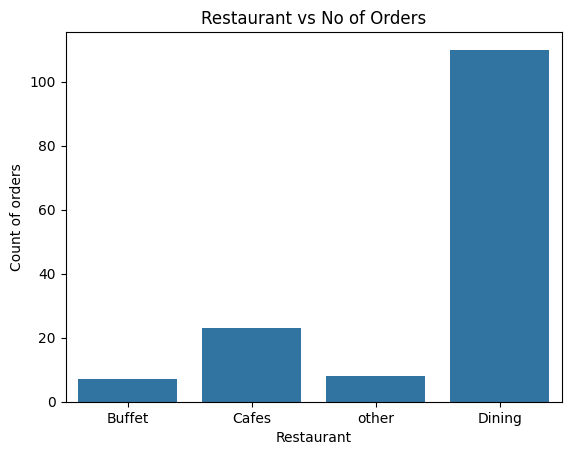

In [33]:
sns.countplot(x=data['listed_in(type)'])
plt.title("Restaurant vs No of Orders")
plt.xlabel("Restaurant")
plt.ylabel("Count of orders")
plt.show()

## from the above graph the dining restaurants receive more orders  

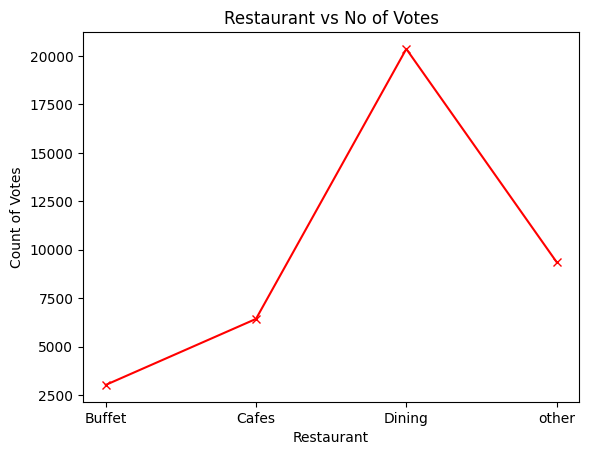

In [44]:
grouped_data=data.groupby('listed_in(type)')['votes'].sum()
result=pd.DataFrame({'votes':grouped_data})
plt.plot(result,color="red",marker="x")
plt.title("Restaurant vs No of Votes")
plt.xlabel("Restaurant")
plt.ylabel("Count of Votes")
plt.show()


### from the above graph the dining restaurants receive more votes 

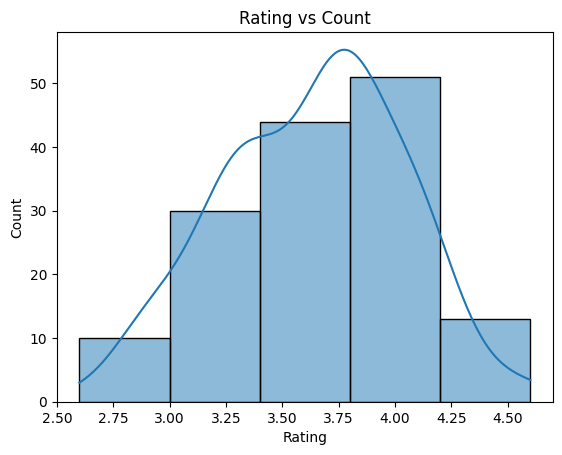

In [49]:
sns.histplot(x=data['rate'],data=data,bins=5,kde=True)
plt.title("Rating vs Count")
plt.xlabel("Rating")
plt.ylabel("Count")
plt.show()


### from the above graph we can observe that majority of the restaurants receive rating between 3.5 to 4  

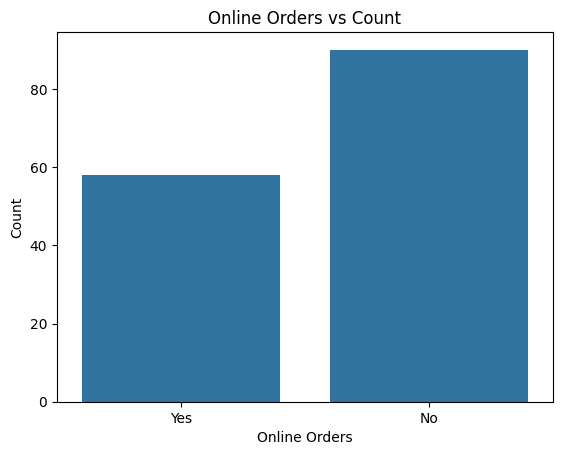

In [66]:
sns.countplot(x=data['online_order'],data=data)
plt.title("Online Orders vs Count")
plt.xlabel("Online Orders")
plt.ylabel("Count")
plt.show()


### from the above graph we can observe that most of the people order food in offline mode 

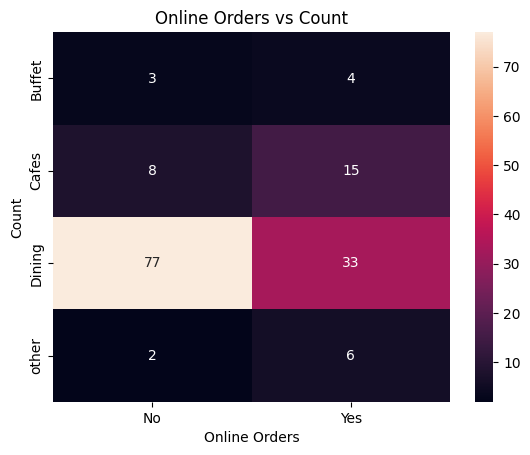

In [75]:
pivot_table=data.pivot_table(index="listed_in(type)",columns="online_order",aggfunc='size',fill_value=0)
sns.heatmap(pivot_table,annot=True)
plt.title("Online Orders vs Count")
plt.xlabel("Online Orders")
plt.ylabel("Count")
plt.show()